# 02b — Extract FOOOF/specparam features

This notebook adds FOOOF/specparam features to the recording-level EEG feature set.

The previous notebook extracted conventional Welch band-power features, especially posterior 8–12 Hz alpha power. This notebook uses the same cleaned spectra but fits a spectral parameterization model to estimate more complex alpha-peak features.

Main output:

- `data_processed/fooof_features.csv`

This file will later be merged with `recording_features.csv`.


## What this notebook does

For each recording:

1. Load the raw EDF file.
2. Keep EEG channels only.
3. Apply the same preprocessing as before:
   - 50 Hz notch filter;
   - 1–40 Hz band-pass filter.
4. Split into 30-second epochs.
5. Reject epochs with peak-to-peak amplitude above 500 µV.
6. Compute the posterior-channel average PSD.
7. Fit FOOOF/specparam to the average PSD.
8. Extract alpha peak and aperiodic features.

FOOOF/specparam is not fitted to every epoch. It is fitted once per recording using the average spectrum from retained epochs.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from scipy.signal import welch
from tqdm.auto import tqdm

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Try both package names.
# Newer versions use `specparam`; older versions use `fooof`.
try:
    from specparam import SpectralModel
    SPECPARAM_BACKEND = "specparam"
except ImportError:
    try:
        from fooof import FOOOF
        SPECPARAM_BACKEND = "fooof"
    except ImportError as error:
        raise ImportError(
            "Neither specparam nor fooof is installed. "
            "Install one of them before running this notebook. "
            "Try: pip install specparam"
        ) from error

print("Using backend:", SPECPARAM_BACKEND)


Using backend: fooof


C:\Users\maria\AppData\Local\Temp\ipykernel_8112\561695092.py:22: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [2]:
# Change this only if the project folder moves.
PROJECT_ROOT = Path(r"C:\Users\maria\Desktop\EEG-special-course")

MANIFEST_FILE = PROJECT_ROOT / "data_processed" / "manifest.csv"
RECORDING_FEATURES_FILE = PROJECT_ROOT / "data_processed" / "recording_features.csv"

PROCESSED_DIR = PROJECT_ROOT / "data_processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

FOOOF_FEATURES_FILE = PROCESSED_DIR / "fooof_features.csv"
FOOOF_ERRORS_FILE = PROCESSED_DIR / "fooof_errors.csv"

PROCESSED_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

manifest = pd.read_csv(MANIFEST_FILE)
recording_features = pd.read_csv(RECORDING_FEATURES_FILE)

print("Manifest:", manifest.shape)
print("Recording features:", recording_features.shape)

manifest.head()


Manifest: (1216, 11)
Recording features: (1216, 62)


,recording_id,participant_id,pair_id,session,acquisition,condition,age,sex,handedness,eeg_path,complete_pair
0,sub-001_ses-1_pre_EC,sub-001,sub-001_ses-1_pre,1,pre,EC,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
1,sub-001_ses-1_pre_EO,sub-001,sub-001_ses-1_pre,1,pre,EO,60,F,right,data/ds005385/sub-001/ses-1/eeg/sub-001_ses-1_...,True
2,sub-002_ses-1_pre_EC,sub-002,sub-002_ses-1_pre,1,pre,EC,67,M,right,data/ds005385/sub-002/ses-1/eeg/sub-002_ses-1_...,True
3,sub-002_ses-1_pre_EO,sub-002,sub-002_ses-1_pre,1,pre,EO,67,M,right,data/ds005385/sub-002/ses-1/eeg/sub-002_ses-1_...,True
4,sub-003_ses-1_pre_EC,sub-003,sub-003_ses-1_pre,1,pre,EC,44,F,right,data/ds005385/sub-003/ses-1/eeg/sub-003_ses-1_...,True


## 1. Fixed settings

These settings are intentionally aligned with the previous preprocessing notebook.


In [3]:
# Preprocessing
NOTCH_FREQ = 50
L_FREQ = 1
H_FREQ = 40

# Epoching
EPOCH_LENGTH_SEC = 30
EPOCH_OVERLAP_SEC = 0

# Same simple artefact rejection threshold used previously.
PTP_REJECT_THRESHOLD_V = 500e-6

# Welch PSD settings
PSD_FMIN = 1
PSD_FMAX = 40
WELCH_WINDOW_SEC = 4
WELCH_OVERLAP_SEC = 2

# FOOOF/specparam fit settings
FOOOF_FMIN = 2
FOOOF_FMAX = 40

# We search a slightly wider range than 8–12 Hz because individual alpha peaks
# can be slightly outside the classical alpha band.
ALPHA_PEAK_MIN = 7
ALPHA_PEAK_MAX = 14

# Posterior channel set fixed from the inspection notebook.
POSTERIOR_CHANNELS = [
    "P7", "P3", "Pz", "P4", "P8",
    "PO9", "O1", "Oz", "O2", "PO10",
    "P5", "P1", "P2", "P6",
    "PO7", "PO3", "POz", "PO4", "PO8",
]

print("N posterior channels:", len(POSTERIOR_CHANNELS))


N posterior channels: 19


## 2. Helper functions

In [4]:
def load_raw_eeg(row, preload=True):
    """Load one EDF recording and keep EEG channels only."""
    eeg_file = PROJECT_ROOT / row["eeg_path"]
    raw = mne.io.read_raw_edf(eeg_file, preload=preload, verbose=False)
    raw.pick("eeg")
    return raw


def preprocess_raw(raw):
    """Apply the same preprocessing as in notebook 02."""
    raw = raw.copy().load_data()
    raw.notch_filter(freqs=NOTCH_FREQ, verbose=False)
    raw.filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        method="fir",
        phase="zero",
        verbose=False,
    )
    return raw


def make_fixed_length_epochs_array(raw):
    """Return non-overlapping epoch data as array: epochs x channels x samples."""
    sfreq = raw.info["sfreq"]
    epoch_samples = int(EPOCH_LENGTH_SEC * sfreq)
    step_samples = int((EPOCH_LENGTH_SEC - EPOCH_OVERLAP_SEC) * sfreq)

    data = raw.get_data()
    n_samples = data.shape[1]

    starts = np.arange(0, n_samples - epoch_samples + 1, step_samples)

    epochs = []
    for start in starts:
        stop = start + epoch_samples
        epochs.append(data[:, start:stop])

    if len(epochs) == 0:
        return np.empty((0, data.shape[0], epoch_samples)), starts

    return np.stack(epochs, axis=0), starts


def epoch_qc_mask(epoch_data):
    """Reject epochs with excessive peak-to-peak amplitude in any EEG channel."""
    if epoch_data.shape[0] == 0:
        return np.array([], dtype=bool), np.array([])

    ptp_per_epoch_channel = np.ptp(epoch_data, axis=2)
    max_ptp_per_epoch = ptp_per_epoch_channel.max(axis=1)
    keep_mask = max_ptp_per_epoch <= PTP_REJECT_THRESHOLD_V

    return keep_mask, max_ptp_per_epoch


def compute_epoch_psd(epoch, sfreq):
    """Compute Welch PSD for one epoch.

    Input:
        epoch: channels x samples, in volts

    Returns:
        freqs: frequency vector
        psd: channels x frequencies, in V^2/Hz
    """
    nperseg = int(WELCH_WINDOW_SEC * sfreq)
    noverlap = int(WELCH_OVERLAP_SEC * sfreq)

    freqs, psd = welch(
        epoch,
        fs=sfreq,
        nperseg=nperseg,
        noverlap=noverlap,
        axis=-1,
        detrend="constant",
        scaling="density",
    )

    freq_mask = (freqs >= PSD_FMIN) & (freqs <= PSD_FMAX)
    return freqs[freq_mask], psd[:, freq_mask]


def compute_recording_posterior_psd(row):
    """Return average posterior PSD across retained epochs for one recording."""
    raw = load_raw_eeg(row, preload=True)
    raw_filt = preprocess_raw(raw)

    sfreq = raw_filt.info["sfreq"]
    ch_names = raw_filt.ch_names

    posterior_channels = [
        ch for ch in POSTERIOR_CHANNELS
        if ch in ch_names
    ]

    if len(posterior_channels) == 0:
        raise ValueError("No posterior channels found.")

    posterior_picks = [ch_names.index(ch) for ch in posterior_channels]

    epochs, starts = make_fixed_length_epochs_array(raw_filt)
    keep_mask, max_ptp = epoch_qc_mask(epochs)

    if keep_mask.sum() == 0:
        raise ValueError("No retained epochs.")

    posterior_psds = []

    for epoch in epochs[keep_mask]:
        freqs, psd = compute_epoch_psd(epoch, sfreq)

        # Average over posterior channels for this epoch.
        posterior_mean_psd = psd[posterior_picks, :].mean(axis=0)
        posterior_psds.append(posterior_mean_psd)

    # Average across retained epochs.
    posterior_psd = np.mean(np.stack(posterior_psds, axis=0), axis=0)

    return {
        "freqs": freqs,
        "posterior_psd": posterior_psd,
        "n_epochs_total": len(epochs),
        "n_epochs_retained": int(keep_mask.sum()),
        "n_posterior_channels": len(posterior_channels),
    }


def fit_spectral_model(freqs, power_spectrum):
    """Fit FOOOF/specparam model to one power spectrum."""
    fit_mask = (freqs >= FOOOF_FMIN) & (freqs <= FOOOF_FMAX)
    fit_freqs = freqs[fit_mask]
    fit_power = power_spectrum[fit_mask]

    # FOOOF/specparam expects positive power values.
    fit_power = np.maximum(fit_power, np.finfo(float).tiny)

    if SPECPARAM_BACKEND == "specparam":
        model = SpectralModel(
            peak_width_limits=(1, 8),
            max_n_peaks=6,
            min_peak_height=0.1,
            aperiodic_mode="fixed",
            verbose=False,
        )
        model.fit(fit_freqs, fit_power)

    else:
        model = FOOOF(
            peak_width_limits=(1, 8),
            max_n_peaks=6,
            min_peak_height=0.1,
            aperiodic_mode="fixed",
            verbose=False,
        )
        model.fit(fit_freqs, fit_power)

    return model


def extract_model_outputs(model):
    """Extract alpha peak and aperiodic parameters from a fitted model."""
    # Compatible with both fooof and specparam-style objects.
    peak_params = np.asarray(model.peak_params_)
    aperiodic_params = np.asarray(model.aperiodic_params_)

    out = {
        "fooof_r_squared": getattr(model, "r_squared_", np.nan),
        "fooof_error": getattr(model, "error_", np.nan),
        "fooof_n_peaks": 0 if peak_params.size == 0 else peak_params.shape[0],
        "fooof_aperiodic_offset": np.nan,
        "fooof_aperiodic_exponent": np.nan,
        "fooof_has_alpha_peak": False,
        "fooof_alpha_cf": np.nan,
        "fooof_alpha_peak_power": np.nan,
        "fooof_alpha_bandwidth": np.nan,
    }

    if aperiodic_params.size >= 2:
        out["fooof_aperiodic_offset"] = aperiodic_params[0]
        out["fooof_aperiodic_exponent"] = aperiodic_params[1]

    if peak_params.size > 0:
        # peak_params columns are usually:
        # center frequency, peak power, bandwidth
        alpha_mask = (
            (peak_params[:, 0] >= ALPHA_PEAK_MIN)
            & (peak_params[:, 0] <= ALPHA_PEAK_MAX)
        )

        if np.any(alpha_mask):
            alpha_peaks = peak_params[alpha_mask]

            # Choose the strongest alpha-range peak.
            best_idx = np.argmax(alpha_peaks[:, 1])
            best_peak = alpha_peaks[best_idx]

            out["fooof_has_alpha_peak"] = True
            out["fooof_alpha_cf"] = best_peak[0]
            out["fooof_alpha_peak_power"] = best_peak[1]
            out["fooof_alpha_bandwidth"] = best_peak[2]

    return out


def process_one_recording_fooof(row):
    """Compute FOOOF/specparam features for one recording."""
    base = {
        "recording_id": row["recording_id"],
        "participant_id": row["participant_id"],
        "pair_id": row["pair_id"],
        "condition": row["condition"],
        "age": row.get("age", np.nan),
        "sex": row.get("sex", np.nan),
        "handedness": row.get("handedness", np.nan),
    }

    try:
        psd_info = compute_recording_posterior_psd(row)

        model = fit_spectral_model(
            psd_info["freqs"],
            psd_info["posterior_psd"],
        )

        model_features = extract_model_outputs(model)

        out = {
            **base,
            **model_features,
            "fooof_n_epochs_total": psd_info["n_epochs_total"],
            "fooof_n_epochs_retained": psd_info["n_epochs_retained"],
            "fooof_n_posterior_channels": psd_info["n_posterior_channels"],
            "fooof_include": True,
            "fooof_exclusion_reason": "",
        }

        return out, None

    except Exception as error:
        out = {
            **base,
            "fooof_r_squared": np.nan,
            "fooof_error": np.nan,
            "fooof_n_peaks": np.nan,
            "fooof_aperiodic_offset": np.nan,
            "fooof_aperiodic_exponent": np.nan,
            "fooof_has_alpha_peak": False,
            "fooof_alpha_cf": np.nan,
            "fooof_alpha_peak_power": np.nan,
            "fooof_alpha_bandwidth": np.nan,
            "fooof_n_epochs_total": np.nan,
            "fooof_n_epochs_retained": 0,
            "fooof_n_posterior_channels": np.nan,
            "fooof_include": False,
            "fooof_exclusion_reason": str(error),
        }

        return out, str(error)


## 3. Test on one recording

Before fitting all recordings, test the full FOOOF/specparam pipeline on one example.


In [5]:
test_row = manifest.query("participant_id == 'sub-001' and condition == 'EC'").iloc[0]

psd_info = compute_recording_posterior_psd(test_row)
model = fit_spectral_model(psd_info["freqs"], psd_info["posterior_psd"])
test_features = extract_model_outputs(model)

print("Recording:", test_row["recording_id"])
print("PSD frequency range:", psd_info["freqs"].min(), "-", psd_info["freqs"].max())
print("Retained epochs:", psd_info["n_epochs_retained"])
print("Posterior channels:", psd_info["n_posterior_channels"])
pd.Series(test_features)


Recording: sub-001_ses-1_pre_EC
PSD frequency range: 1.0 - 40.0
Retained epochs: 6
Posterior channels: 19


fooof_r_squared              0.985733
fooof_error                   0.06863
fooof_n_peaks                       5
fooof_aperiodic_offset     -10.746585
fooof_aperiodic_exponent     1.274694
fooof_has_alpha_peak             True
fooof_alpha_cf               9.960222
fooof_alpha_peak_power       1.782206
fooof_alpha_bandwidth             1.0
dtype: object

## 4. Plot one FOOOF/specparam fit

This plot is for checking whether the model fit is reasonable. The exact plotting API differs between package versions, so this cell uses a simple custom plot where possible.


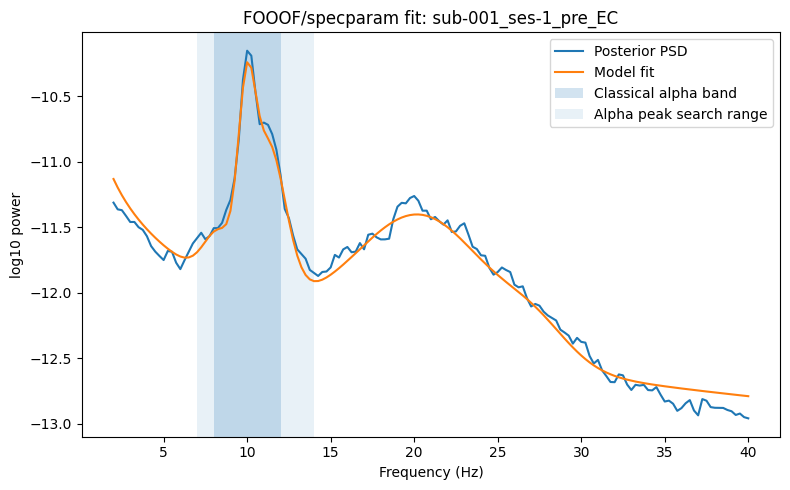

In [6]:
freqs = psd_info["freqs"]
power = psd_info["posterior_psd"]

fit_mask = (freqs >= FOOOF_FMIN) & (freqs <= FOOOF_FMAX)
fit_freqs = freqs[fit_mask]
fit_power = power[fit_mask]

plt.figure(figsize=(8, 5))
plt.plot(fit_freqs, np.log10(np.maximum(fit_power, np.finfo(float).tiny)), label="Posterior PSD")

# Try to overlay full model fit if available.
try:
    model_fit = model.fooofed_spectrum_
    if len(model_fit) == len(fit_freqs):
        plt.plot(fit_freqs, model_fit, label="Model fit")
except Exception:
    pass

plt.axvspan(8, 12, alpha=0.2, label="Classical alpha band")
plt.axvspan(ALPHA_PEAK_MIN, ALPHA_PEAK_MAX, alpha=0.1, label="Alpha peak search range")
plt.xlabel("Frequency (Hz)")
plt.ylabel("log10 power")
plt.title(f"FOOOF/specparam fit: {test_row['recording_id']}")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "fooof_example_fit.png", dpi=300)
plt.show()


## 5. Test on a few recordings

In [7]:
test_manifest = manifest[
    manifest["participant_id"].isin(["sub-001", "sub-002"])
].copy()

test_rows = []
test_errors = []

for _, row in tqdm(test_manifest.iterrows(), total=len(test_manifest)):
    out, error = process_one_recording_fooof(row)
    test_rows.append(out)

    if error is not None:
        test_errors.append({
            "recording_id": row["recording_id"],
            "error": error,
        })

test_fooof = pd.DataFrame(test_rows)

display(test_fooof[[
    "recording_id",
    "condition",
    "fooof_include",
    "fooof_has_alpha_peak",
    "fooof_alpha_cf",
    "fooof_alpha_peak_power",
    "fooof_alpha_bandwidth",
    "fooof_aperiodic_exponent",
    "fooof_r_squared",
    "fooof_error",
]])

print("Errors:", test_errors)


  0%|          | 0/4 [00:00<?, ?it/s]

,recording_id,condition,fooof_include,fooof_has_alpha_peak,fooof_alpha_cf,fooof_alpha_peak_power,fooof_alpha_bandwidth,fooof_aperiodic_exponent,fooof_r_squared,fooof_error
0,sub-001_ses-1_pre_EC,EC,True,True,9.960222,1.782206,1.000000,1.274694,0.985733,0.068630
1,sub-001_ses-1_pre_EO,EO,True,True,10.917563,0.619877,2.877636,1.482230,0.992011,0.037988
2,sub-002_ses-1_pre_EC,EC,True,True,8.988096,1.542343,2.326441,0.730658,0.981638,0.048030
3,sub-002_ses-1_pre_EO,EO,True,True,8.459675,0.523143,1.060943,1.142581,0.930463,0.067997


Errors: []


## 6. Run FOOOF/specparam on all recordings

This may take a while because it fits one spectral model per recording.

If you want to test runtime first, set `RUN_ALL = False`.


In [8]:
RUN_ALL = True

if RUN_ALL:
    fooof_rows = []
    error_rows = []

    for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
        out, error = process_one_recording_fooof(row)
        fooof_rows.append(out)

        if error is not None:
            error_rows.append({
                "recording_id": row["recording_id"],
                "participant_id": row["participant_id"],
                "condition": row["condition"],
                "error": error,
            })

    fooof_features = pd.DataFrame(fooof_rows)
    fooof_features.to_csv(FOOOF_FEATURES_FILE, index=False)

    print("Saved:", FOOOF_FEATURES_FILE)
    print("FOOOF features shape:", fooof_features.shape)

    if len(error_rows) > 0:
        errors_df = pd.DataFrame(error_rows)
        errors_df.to_csv(FOOOF_ERRORS_FILE, index=False)
        print("Errors saved to:", FOOOF_ERRORS_FILE)
        display(errors_df.head())
    else:
        print("No FOOOF processing errors.")
else:
    print("RUN_ALL is False. Full FOOOF extraction was skipped.")


  0%|          | 0/1216 [00:00<?, ?it/s]

Saved: C:\Users\maria\Desktop\EEG-special-course\data_processed\fooof_features.csv
FOOOF features shape: (1216, 21)
Errors saved to: C:\Users\maria\Desktop\EEG-special-course\data_processed\fooof_errors.csv


,recording_id,participant_id,condition,error
0,sub-004_ses-1_pre_EO,sub-004,EO,No retained epochs.
1,sub-013_ses-1_pre_EC,sub-013,EC,No retained epochs.
2,sub-013_ses-1_pre_EO,sub-013,EO,No retained epochs.
3,sub-079_ses-1_pre_EC,sub-079,EC,No retained epochs.
4,sub-288_ses-1_pre_EO,sub-288,EO,No retained epochs.


## 7. Summarize FOOOF/specparam features

In [9]:
if FOOOF_FEATURES_FILE.exists():
    fooof_features = pd.read_csv(FOOOF_FEATURES_FILE)

    print("FOOOF features:", fooof_features.shape)

    display(fooof_features[[
        "recording_id",
        "condition",
        "fooof_include",
        "fooof_has_alpha_peak",
        "fooof_alpha_cf",
        "fooof_alpha_peak_power",
        "fooof_alpha_bandwidth",
        "fooof_aperiodic_exponent",
        "fooof_r_squared",
        "fooof_error",
    ]].head())

    print("\nInclusion counts:")
    display(fooof_features["fooof_include"].value_counts(dropna=False))

    print("\nAlpha peak counts:")
    display(fooof_features["fooof_has_alpha_peak"].value_counts(dropna=False))

    print("\nFit-quality summary:")
    display(fooof_features[[
        "fooof_r_squared",
        "fooof_error",
        "fooof_alpha_cf",
        "fooof_alpha_peak_power",
        "fooof_alpha_bandwidth",
        "fooof_aperiodic_exponent",
    ]].describe())
else:
    print("FOOOF features file not found yet.")


FOOOF features: (1216, 21)


,recording_id,condition,fooof_include,fooof_has_alpha_peak,fooof_alpha_cf,fooof_alpha_peak_power,fooof_alpha_bandwidth,fooof_aperiodic_exponent,fooof_r_squared,fooof_error
0,sub-001_ses-1_pre_EC,EC,True,True,9.960222,1.782206,1.000000,1.274694,0.985733,0.068630
1,sub-001_ses-1_pre_EO,EO,True,True,10.917563,0.619877,2.877636,1.482230,0.992011,0.037988
2,sub-002_ses-1_pre_EC,EC,True,True,8.988096,1.542343,2.326441,0.730658,0.981638,0.048030
3,sub-002_ses-1_pre_EO,EO,True,True,8.459675,0.523143,1.060943,1.142581,0.930463,0.067997
4,sub-003_ses-1_pre_EC,EC,True,True,11.134837,1.384780,1.672261,1.286155,0.989154,0.047964



Inclusion counts:


fooof_include
True     1208
False       8
Name: count, dtype: int64


Alpha peak counts:


fooof_has_alpha_peak
True     1151
False      65
Name: count, dtype: int64


Fit-quality summary:


,fooof_r_squared,fooof_error,fooof_alpha_cf,fooof_alpha_peak_power,fooof_alpha_bandwidth,fooof_aperiodic_exponent
count,1208.000000,1208.000000,1151.000000,1151.000000,1151.000000,1208.000000
mean,0.982388,0.048483,10.100252,0.962242,1.970589,1.303014
std,0.025235,0.016696,1.275943,0.582030,1.043818,0.304573
min,0.603933,0.022480,7.013995,0.039539,1.000000,0.046656
25%,0.982019,0.036478,9.271713,0.467465,1.040532,1.134184
50%,0.988022,0.044839,10.040744,0.893383,1.728572,1.330223
75%,0.991771,0.056928,10.837602,1.421916,2.499590,1.506708
max,0.997114,0.144896,13.986406,2.521209,8.000000,2.207116


## 8. Check alpha peak detection by condition

fooof_has_alpha_peak,False,True,All
condition,,,
EC,11,597,608
EO,54,554,608
All,65,1151,1216


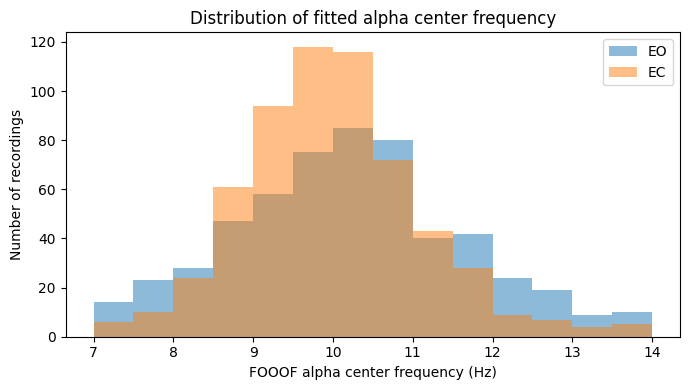

In [10]:
if FOOOF_FEATURES_FILE.exists():
    display(pd.crosstab(
        fooof_features["condition"],
        fooof_features["fooof_has_alpha_peak"],
        margins=True
    ))

    plt.figure(figsize=(7, 4))

    for condition in ["EO", "EC"]:
        values = fooof_features.loc[
            (fooof_features["condition"] == condition)
            & (fooof_features["fooof_has_alpha_peak"]),
            "fooof_alpha_cf",
        ].dropna()

        plt.hist(values, bins=np.arange(7, 14.5, 0.5), alpha=0.5, label=condition)

    plt.xlabel("FOOOF alpha center frequency (Hz)")
    plt.ylabel("Number of recordings")
    plt.title("Distribution of fitted alpha center frequency")
    plt.legend()
    plt.tight_layout()

    plt.savefig(FIGURES_DIR / "fooof_alpha_cf_distribution.png", dpi=300)
    plt.show()


## 9. Merge check with Welch recording features

This does not overwrite `recording_features.csv`. It only checks that the FOOOF table can be joined later.


In [11]:
if FOOOF_FEATURES_FILE.exists():
    merged_check = recording_features.merge(
        fooof_features,
        on=["recording_id", "participant_id", "pair_id", "condition", "age", "sex", "handedness"],
        how="left",
        validate="one_to_one",
    )

    print("Merged shape:", merged_check.shape)
    print("Missing FOOOF rows after merge:", merged_check["fooof_include"].isna().sum())

    display(merged_check[[
        "recording_id",
        "condition",
        "posterior_alpha_log",
        "fooof_has_alpha_peak",
        "fooof_alpha_cf",
        "fooof_alpha_peak_power",
        "fooof_aperiodic_exponent",
    ]].head())


Merged shape: (1216, 76)
Missing FOOOF rows after merge: 0


,recording_id,condition,posterior_alpha_log,fooof_has_alpha_peak,fooof_alpha_cf,fooof_alpha_peak_power,fooof_aperiodic_exponent
0,sub-001_ses-1_pre_EC,EC,-10.070651,True,9.960222,1.782206,1.274694
1,sub-001_ses-1_pre_EO,EO,-10.935722,True,10.917563,0.619877,1.482230
2,sub-002_ses-1_pre_EC,EC,-10.093279,True,8.988096,1.542343,0.730658
3,sub-002_ses-1_pre_EO,EO,-11.024193,True,8.459675,0.523143,1.142581
4,sub-003_ses-1_pre_EC,EC,-10.851223,True,11.134837,1.384780,1.286155
